<a href="https://colab.research.google.com/github/andres-merino/Curso-FundMachineLearning/blob/main/4-Ejercicios/03-Agrupamiento-kMeans.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<table style="border: none; border-collapse: collapse;">
    <tr>
        <td style="width: 20%; vertical-align: middle; padding-right: 10px;">
            <img src="https://i0.wp.com/see-ec.org/wordpress/wp-content/uploads/2023/01/LOGO-SEE-texto-blanco-3.png?w=1356&ssl=1" width="200">
        </td>
        <td style="width: 2px; text-align: center;">
            <font color="#008dc3" size="7">|</font><br>
            <font color="#008dc3" size="7">|</font>
        </td>
        <td>
            <p style="font-variant: small-caps;"><font color="#008dc3" size="5">
                <b>Sociedad Ecuatoriana de Estadística</b>
            </font> </p>
            <p style="font-variant: small-caps;"><font color="#008dc3" size="4">
                Aprendizaje Automático Inicial &bull; Agrupamiento k-Means
            </font></p>
            <p style="font-style: oblique;"><font color="#008dc3" size="3">
                Andrés Merino &bull; 2025-04
            </font></p>
        </td>  
    </tr>
</table>

---
## <font color='008dc3'> Introducción </font>

A lo largo de este taller, aplicaremos el algoritmo de agrupamiento jerárquico a un conjunto de datos.

Los paquetes necesarios son:

In [13]:
# Paquet
import pandas as pd  # Manejo de datos
import numpy as np  # Operaciones matemáticas y arreglos
import matplotlib.pyplot as plt  # Visualización
import plotly.express as px # Para visualización interactiva

from sklearn.preprocessing import StandardScaler  # Estandarización de datos

from sklearn.datasets import make_blobs # Creación de datos de prueba
from sklearn.cluster import KMeans  # Algoritmo K-means
from sklearn.decomposition import PCA # Análisis de componentes principaleses necesarios


---
## <font color='008dc3'> Preprocesamiento de datos </font>

Primero necesitas el conjunto de datos. Los datos a utilzar son los seleccionados en la clase aterior.

<div style="background-color: #edf1f8; border-color: #008dc3; border-left: 5px solid #008dc3; padding: 0.5em;">
<strong>Ejercicio:</strong><br>
    Carga el conjunto de datos y procésalos:
<ul>
  <li>Muestra algunos datos.</li>
  <li>Muestra una descripción de los datos.</li>
  <li>Escala los datos si es necesario.</li>
</ul>
</div>

In [14]:
# Leer los datos
data = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/00292/Wholesale%20customers%20data.csv')

# Muestro los primeros registros
display(data.head())

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


In [15]:
data.describe()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000
mean,1.322727,2.543182,12000.297727,5796.265909,7951.277273,3071.931818,2881.493182,1524.870455
std,0.468052,0.774272,12647.328865,7380.377175,9503.162829,4854.673333,4767.854448,2820.105937
min,1.000000,1.000000,3.000000,55.000000,3.000000,25.000000,3.000000,3.000000
25%,1.000000,2.000000,3127.750000,1533.000000,2153.000000,742.250000,256.750000,408.250000
50%,1.000000,3.000000,8504.000000,3627.000000,4755.500000,1526.000000,816.500000,965.500000
75%,2.000000,3.000000,16933.750000,7190.250000,10655.750000,3554.250000,3922.000000,1820.250000
max,2.000000,3.000000,112151.000000,73498.000000,92780.000000,60869.000000,40827.000000,47943.000000


In [16]:
# Seleccionar solo las columnas de productos (continuas)
data_products = data.drop(['Channel', 'Region'], axis=1)

# Aplicar escalamiento estándar (StandardScaler)
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_products)

# Convertir de nuevo a DataFrame para visualizar
X= pd.DataFrame(data_scaled, columns=data_products.columns)

print("\nDatos escalados (Primeras 5 filas):")
print(X.head())


Datos escalados (Primeras 5 filas):
      Fresh      Milk   Grocery    Frozen  Detergents_Paper  Delicassen
0  0.052933  0.523568 -0.041115 -0.589367         -0.043569   -0.066339
1 -0.391302  0.544458  0.170318 -0.270136          0.086407    0.089151
2 -0.447029  0.408538 -0.028157 -0.137536          0.133232    2.243293
3  0.100111 -0.624020 -0.392977  0.687144         -0.498588    0.093411
4  0.840239 -0.052396 -0.079356  0.173859         -0.231918    1.299347


---
## <font color='008dc3'> Determinación del número de clusters </font>

<div style="background-color: #edf1f8; border-color: #008dc3; border-left: 5px solid #008dc3; padding: 0.5em;">
<strong>Ejercicio:</strong><br>
    Determina el número óptimo de clústeres para un modelo K-Means utilizando el método del codo.
<ul>
  <li>Genera una gráfica que muestre la inercia frente al número de clústeres (k) en el rango de 1 a 10.</li>
  <li>Identifica visualmente el "codo" en la curva para seleccionar el número óptimo de clústeres.</li>
  <li>De manera intuitiva, explica por qué consideras ese punto como el codo y cómo influye en la calidad de los clústeres.</li>
</ul>
</div>


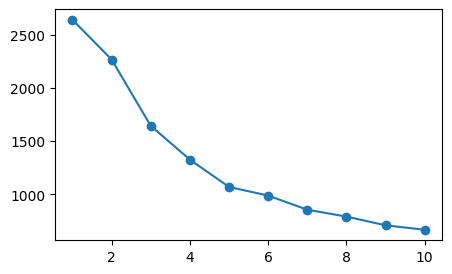

In [17]:
# Metodo del codo
inertia = []
for i in range(1, 11):
    modelo = KMeans(n_clusters=i, random_state=42)
    modelo.fit(X)
    inertia.append(modelo.inertia_)
plt.figure(figsize=(5, 3))
plt.plot(range(1, 11), inertia, marker='o')

entre 3 y 4 esta la curva, tomaria 3 en grupos, en cuanto mas pequeños son los grupos no tendria sentido analizar.

---
## <font color='008dc3'> Asignación de grupos y análisis </font>


<div style="background-color: #edf1f8; border-color: #008dc3; border-left: 5px solid #008dc3; padding: 0.5em;">
<strong>Ejercicio:</strong><br>
    Realiza un análisis de los grupos obtenidos.
<ul>
  <li>Asigna los grupos.</li>
  <li>Revisa la media de cada grupo.</li>
  <li>Revisa el mínimo y máximo de cada grupo.</li>
  <li>Muestra algunos integrantes de cada grupo.</li>
</ul>
</div>

In [18]:
# Realizamos el agrupamiento
modelo = KMeans(n_clusters=3, random_state=42)
modelo.fit(X)

# Asignamos las etiquetas
labels = modelo.labels_

# Agregar la información de clúster como C1, C2, C3, etc.
data_products['Cluster'] = ['C' + str(c) for c in labels]

# Revisar los primeros registros
display(data_products.head())

# Calcular la media de cada grupo
medias_por_cluster = data_products.groupby('Cluster').mean()

print("Promedio de gasto por categoría y clúster:")
display(medias_por_cluster.round(2))
# Calculamos el mínimo y el máximo para cada categoría de producto dentro de los clústeres
min_max_grupos = data_products.groupby('Cluster').agg(['min', 'max'])

print("Límites de gasto (Mínimos y Máximos) por Clúster:")
display(min_max_grupos)

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,Cluster
0,12669,9656,7561,214,2674,1338,C0
1,7057,9810,9568,1762,3293,1776,C0
2,6353,8808,7684,2405,3516,7844,C0
3,13265,1196,4221,6404,507,1788,C0
4,22615,5410,7198,3915,1777,5185,C1


Promedio de gasto por categoría y clúster:


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
Cluster,,,,,,
C0,8935.50,4228.53,5848.03,2167.23,1913.61,1102.12
C1,34540.11,5860.36,6122.62,9841.74,981.47,3664.25
C2,8704.86,20534.41,30466.24,1932.62,14758.84,2459.35


Límites de gasto (Mínimos y Máximos) por Clúster:


Fresh          Milk        Grocery        Frozen         \
          min     max   min    max     min    max    min    max   
Cluster                                                           
C0          3   31812    55  23527       3  28986     25  15601   
C1       4983  112151   286  43950     471  21042    287  60869   
C2         85   44466  3737  73498   13567  92780     36   7782   

        Detergents_Paper        Delicassen         
                     min    max        min    max  
Cluster                                            
C0                     3  10069          3   7844  
C1                    20   4948          3  47943  
C2                  4337  40827         37  16523

In [23]:
for cluster in data_products['Cluster'].unique():
    print(f'Cluster {cluster}: cantidad de elementos { data_products[ data_products["Cluster"] == cluster].shape[0]}')
    display(data_products[ data_products['Cluster'] == cluster].head(5))

Cluster C0: cantidad de elementos 350


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,Cluster
0,12669,9656,7561,214,2674,1338,C0
1,7057,9810,9568,1762,3293,1776,C0
2,6353,8808,7684,2405,3516,7844,C0
3,13265,1196,4221,6404,507,1788,C0


Cluster C1: cantidad de elementos 53


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,Cluster
4,22615,5410,7198,3915,1777,5185,C1
12,31714,12319,11757,287,3881,2931,C1
22,31276,1917,4469,9408,2381,4334,C1
24,22647,9776,13792,2915,4482,5778,C1


Cluster C2: cantidad de elementos 37


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,Cluster
23,26373,36423,22019,5154,4337,16523,C2
28,4113,20484,25957,1158,8604,5206,C2
43,630,11095,23998,787,9529,72,C2
45,5181,22044,21531,1740,7353,4985,C2


<div style="background-color: #edf1f8; border-color: #008dc3; border-left: 5px solid #008dc3; padding: 0.5em;">
<strong>Ejercicio:</strong><br>
    Da una descripción de los grupos obtenidos. Asigna un nombre a cada grupo.
</div>

 c0 puede ser tiendas compra productos no peresibles , c1 pueder ser restaurantes compra productos Fresh, c2 compra en grandes cantidades de todo, parace un distribuidor.

---
## <font color='008dc3'> Visualizaciones  </font>

<div style="background-color: #edf1f8; border-color: #008dc3; border-left: 5px solid #008dc3; padding: 0.5em;">
<strong>Ejercicio:</strong><br>
    Realiza una visualización de los grupos obtenidos en 2D seleccionando dos variables que creas relevantes.
<ul>
  <li>¿Qué tan buenos te parecen los grupos?</li>
</ul>
</div>

In [1]:
plt.figure(figsize=(8, 6))
for cluster in data_products['Cluster'].unique():
    cluster_data = data_products[data_products['Cluster'] == cluster]
    plt.scatter(cluster_data['Milk'], cluster_data['Fresh'], label=f'Cluster {cluster}', alpha=0.7)

plt.xlabel('Gasto en Leche (Milk)')
plt.ylabel('Gasto en Comestibles (Grocery)')
plt.title('Clusters de Clientes (Milk vs Grocery)')
plt.legend()
plt.grid(True)
plt.show()

NameError: name 'plt' is not defined

<div style="background-color: #edf1f8; border-color: #008dc3; border-left: 5px solid #008dc3; padding: 0.5em;">
<strong>Ejercicio:</strong><br>
    Realiza una visualización de los grupos obtenidos en 2D usando reducción de dimensionalidad diferente a PCA.
<ul>
  <li>¿Qué tan buenos te parecen los grupos?</li>
  <li>Indica el porcentaje de la variaza explicada en el gráfico, ¿afecta esto a tu visualización?</li>
</ul>
</div>

---
## <font color='008dc3'> Métricas  </font>

<div style="background-color: #edf1f8; border-color: #008dc3; border-left: 5px solid #008dc3; padding: 0.5em;">
<strong>Ejercicio:</strong><br>
Calcula la métrica de la silueta para los grupos obtenidos. ¿Qué tan buenos te parecen los grupos?
</div>

In [ ]:
from sklearn.metrics import silhouette_score

# Calcular el coeficiente de silueta
silhouette_avg = silhouette_score(X, labels)

print(f"El coeficiente de silueta promedio es: {silhouette_avg:.2f}")

print("\nInterpretación del coeficiente de silueta:")
print("- Un valor cercano a 1 indica que los clústeres están bien separados y los puntos están densamente agrupados dentro de sus clústeres.\n")
print("- Un valor cercano a 0 indica que los clústeres se superponen o que los puntos están en la frontera de dos clústeres.\n")
print("- Un valor negativo indica que los puntos podrían haber sido asignados al clúster equivocado.")

if silhouette_avg > 0.5:
    print("\nCon base en el coeficiente de silueta, los grupos parecen ser bastante buenos y bien definidos.")
elif silhouette_avg > 0.25:
    print("\nCon base en el coeficiente de silueta, los grupos son aceptables, pero podría haber cierta superposición.")
else:
    print("\nCon base en el coeficiente de silueta, los grupos no están bien definidos y hay una considerable superposición o mala asignación.")

El coeficiente de silueta promedio es: 0.46

Interpretación del coeficiente de silueta:
- Un valor cercano a 1 indica que los clústeres están bien separados y los puntos están densamente agrupados dentro de sus clústeres.

- Un valor cercano a 0 indica que los clústeres se superponen o que los puntos están en la frontera de dos clústeres.

- Un valor negativo indica que los puntos podrían haber sido asignados al clúster equivocado.

Con base en el coeficiente de silueta, los grupos son aceptables, pero podría haber cierta superposición.
